## Project 1 - What factors most influence Airbnb rental prices across major cities?

Uploading all sorts of imports and functions from class10

In [1]:
#pip install numpy==1.24.3 --force-reinstall


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
import seaborn as sns
import cv2

from matplotlib.colors import LogNorm
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import add_dummy_feature
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from matplotlib.colors import ListedColormap
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error

In [3]:
sns.axes_style("whitegrid")
sns.set_context("paper")
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
# this cell is intended to map the species type to an integer (1,2,3)
# for the color map

def tokenize_species(s_data):

  seto = s_data['species']=="Iris-setosa"; pseto = np.array(seto)
  vers = s_data['species']=="Iris-versicolor"; pver = np.array(vers)
  vir = s_data['species']=="Iris-virginica"; pvir = np.array(vir)

#  print(len(seto))
  s_data_coded=np.zeros(len(seto))
  for i in range(len(seto)):
    if (pseto[i]==1):
      s_data_coded[i]=1

  for i in range(len(vers)):
    if (pver[i]==1):
      s_data_coded[i]=2

  for i in range(len(vir)):
    if (pvir[i]==1):
      s_data_coded[i]=3
  return s_data_coded

In [5]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred)
    mse=metrics.mean_squared_error(y_true, y_pred)
#    mean_squared_log_error=metrics.mean_squared_log_error(y_true, y_pred)
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))
    print('mean_absolute_error: ', round(mean_absolute_error,4))
#    print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))


In [6]:
def model_acc(res):  # format of res should be predictions in column0, and actual in column1
    bad=0; good=0
    pred=res['pred']
    act= res['actual']

# need to keep track of good and bad predictions
#    bdata=np.zeros[len(res)]
    for i in range(len(pred)): # loop over all items
      if pred[i] >=0.5:  # if prob is >50%
        if act[i] == True: # and if flower is virginica
          good=good+1  # keep track of success
        else:
          bad=bad+1
          # keep track of failure number and location
#          bdata[i]=X_train[i] # should be the feature values from training data
      elif pred[i] <0.5:
        if act[i] == False: # correctly identifying false is also success
          good=good+1
        else:
          bad=bad+1
#          bdata[i]=X_train[i] # should be the feature values from training data

    print("Your model made ", good/len(pred)*100, "percent correct predictions\n")
# return the feature values that led to bad predictions
#    return bdata
    return

In [7]:
def model_acc_bad(res):  # format of res should be predictions in column0, and actual in column1
    bad=0; good=0
    pred=res['pred']
    act= res['actual']

# need to keep track of good and bad predictions
    bd = len(res['pred'])
    bdata=np.zeros((bd,2))
    for i in range(len(pred)): # loop over all items
      if pred[i] >=0.5:  # if prob is >50%
        if act[i] == True: # and if flower is virginica
          good=good+1  # keep track of success
        else:
          bad=bad+1
          # keep track of failure number and location
          bdata[i,0]=X_train[i][0] # should be the feature values from training data
          bdata[i,1]=X_train[i][1] # should be the feature values from training data

      elif pred[i] <0.5:
        if act[i] == False: # correctly identifying false is also success
          good=good+1
        else:
          bad=bad+1
#          bdata[i,j]=X_train[i] # should be the feature values from training data
          bdata[i,0]=X_train[i][0] # should be the feature values from training data
          bdata[i,1]=X_train[i][1] # should be the feature values from training data

    print("Your model made ", good/len(pred)*100, "percent correct predictions\n")
# return the feature values that led to bad predictions
    return bdata
#    return

In [8]:
#model_acc2(res_df,type) # 0 for setosa, 1 for versi, 2 for virg

# need condition for each type
def model_acc2(res,type):

    if (type==0):
      m1 = res['pred']>=0.5
      m2 = res['actual']==1
    elif (type==1):
      m1 = res['pred']>=0.5
      m2 = res['actual']==1
    elif (type==2):
      m1 = res['pred']>=0.5
      m2 = res['actual']==1


#    m1 = res['pred']>=0.5
#    m2 = res['actual']==1
    sum12=sum(m1==m2)
    pct=sum12/len(res)*100
    print("Your model made ", pct, "percent correct predictions\n")
    return

In [9]:
def model_acc_t(res):

    m1 = res['pred']; m2 = res['actual']
    sum12 = sum(m1==m2)
    pct=sum12/len(res)*100

    print("Your model made ", pct, "percent correct predictions\n")
    return

In [10]:
def model_parm_std_err(xdata, ydata, model): # assumes xtest and ytest are not dfs
# this function was written for univariate regression,
# not yet tested for multivariate

# if you just want to check whether this algorithm works, use statsmodels

# using this with scaled data (both x and y) gives the same slope
# but a different intercept

    df_xt = pd.DataFrame(xdata)
    df_yt = pd.DataFrame(ydata)

    modelf = model

    N = len(df_xt)
    p = len(df_xt.columns) + 1  # plus one because LinearRegression adds an intercept term

    X_with_intercept = np.empty(shape=(N, p), dtype=float)
    X_with_intercept[:, 0] = 1
    X_with_intercept[:, 1:p] = xdata


    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ ydata

    #print(beta_hat)

    modelf.fit(xdata,ydata)

    slope = modelf.coef_[0][0]
    intercept = modelf.intercept_[0]

    y_hat = modelf.predict(df_xt)
    residuals = ydata - y_hat

    residual_sum_of_squares = residuals.T @ residuals
    sigma_squared_hat = residual_sum_of_squares[0, 0] / (N - p)
    var_beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) * sigma_squared_hat


# var_beta hat output errors on intercept first, then slope1, slope2, etc.
    for p_ in range(p):
      standard_error = var_beta_hat[p_, p_] ** 0.5
#      print(var_beta_hat.shape)
#      print(f"SE(beta_hat[{p_}]): {standard_error}")

    print ("slope:\t", slope, "+/-", var_beta_hat[1,1]**0.5, "\nintercept:\t", intercept, "+/-", var_beta_hat[0,0]**0.5)


In [11]:
def lasso_model_parm_std_err(xdata, ydata, model): # assumes xtest and ytest are not dfs
# this function was written for univariate regression for the lasso model which
# is formatted differently

# if you just want to check whether this algorithm works, use statsmodels

# using this with scaled data (both x and y) gives the same slope
# but a different intercept

    df_xt = pd.DataFrame(xdata)
    df_yt = pd.DataFrame(ydata)

    modelf = model

    N = len(df_xt)
    p = len(df_xt.columns) + 1  # plus one because LinearRegression adds an intercept term

    X_with_intercept = np.empty(shape=(N, p), dtype=float)
    X_with_intercept[:, 0] = 1
    X_with_intercept[:, 1:p] = xdata


    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ ydata

    #print(beta_hat)

    modelf.fit(xdata,ydata)

# format for lasso
    slope = modelf.coef_[0]
    intercept = modelf.intercept_[0]


    y_hat = modelf.predict(df_xt)
    residuals = ydata - y_hat

    residual_sum_of_squares = residuals.T @ residuals
    sigma_squared_hat = residual_sum_of_squares[0, 0] / (N - p)
    var_beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) * sigma_squared_hat


# var_beta hat output errors on intercept first, then slope1, slope2, etc.
    for p_ in range(p):
      standard_error = var_beta_hat[p_, p_] ** 0.5
#      print(var_beta_hat.shape)
#      print(f"SE(beta_hat[{p_}]): {standard_error}")

    print ("slope:\t", slope, "+/-", var_beta_hat[1,1]**0.5, "\nintercept:\t", intercept, "+/-", var_beta_hat[0,0]**0.5)

In [12]:
def mv_model_parm_std_err(xdata, ydata, model): # assumes xdata and ydata are not dfs
# this function was written for multivariate regression for the lasso model which
# is formatted differently

    df_xt = pd.DataFrame(xdata)
    df_yt = pd.DataFrame(ydata)

    modelf = model

    N = len(df_xt)
    p = len(df_xt.columns) + 1  # plus one because LinearRegression adds an intercept term

    X_with_intercept = np.empty(shape=(N, p), dtype=float)
    X_with_intercept[:, 0] = 1
    X_with_intercept[:, 1:p] = xdata

    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ ydata

    #print(beta_hat)

    modelf.fit(xdata,ydata)

# format for lasso
    slope = []
    for i in range(len(modelf.coef_)):
      slope.append(modelf.coef_[i])

#    slope = modelf.coef_[0]
    intercept = modelf.intercept_[0]


    y_hat = modelf.predict(df_xt)
    residuals = ydata - y_hat

    residual_sum_of_squares = residuals.T @ residuals
    sigma_squared_hat = residual_sum_of_squares[0, 0] / (N - p)
    var_beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) * sigma_squared_hat


# var_beta hat output errors on intercept first, then slope1, slope2, etc.
    for p_ in range(p):
      standard_error = var_beta_hat[p_, p_] ** 0.5
#      print(var_beta_hat.shape)
#      print(f"SE(beta_hat[{p_}]): {standard_error}")

    for p_ in range(p):
      std_err = var_beta_hat[p_,p_]**0.5
      if(p_==0):
        print("intercept:\t",intercept,"+/-",std_err,"\n")
        continue
#          print("slope",p_,":\t",slope[p_],"+/-",std_err,"\n")
#      else:
      print("slope",p_,":\t",slope[p_-1],"+/-",std_err,"\n")

#    print ("slope:\t", slope, "+/-", var_beta_hat[1,1]**0.5, "\nintercept:\t", intercept, "+/-", var_beta_hat[0,0]**0.5)

## Uploading Data for Paris

In [13]:
#web_path = '' #if downloaded data to the current folder
web_path = 'http://public.gettysburg.edu/~eeleth01/' #if using data over web
#df = pd.read_csv(web_path+'SS_Report_27_8_24.csv')
dfp = pd.read_csv(web_path+'Paris.csv')

dfp.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,12/3/2011,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃ‚Â² Paris (Sacre CÃ…â€œur),10328771,11/29/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,7/31/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,12/17/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,12/14/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


## Cleaning dataset


In [14]:
dfp.columns = dfp.columns.str.strip().str.lower()  # Removes spaces and converts to lowercase
dfp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64690 entries, 0 to 64689
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   64690 non-null  int64  
 1   name                         64627 non-null  object 
 2   host_id                      64690 non-null  int64  
 3   host_since                   64657 non-null  object 
 4   host_location                64522 non-null  object 
 5   host_response_time           23346 non-null  object 
 6   host_response_rate           23346 non-null  float64
 7   host_acceptance_rate         31919 non-null  float64
 8   host_is_superhost            64657 non-null  object 
 9   host_total_listings_count    64657 non-null  float64
 10  host_has_profile_pic         64657 non-null  object 
 11  host_identity_verified       64657 non-null  object 
 12  neighbourhood                64690 non-null  object 
 13  district        

In [15]:
dfp["host_since"] = pd.to_datetime(dfp["host_since"]) # converting string to date



In [16]:

columns_to_drop = ['city','listing_id','host_location','host_response_time','host_is_superhost','property_type','room_type','name', 'host_has_profile_pic', 'district', 'host_identity_verified', 'latitude', 'longitude']

# Drop columns 
dfp = dfp.drop(columns=columns_to_drop, errors='ignore')
dfp

,host_id,host_since,host_response_rate,host_acceptance_rate,host_total_listings_count,neighbourhood,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,1466919,2011-12-03,NaN,NaN,1.0,Buttes-Montmartre,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,10328771,2013-11-29,NaN,NaN,1.0,Buttes-Montmartre,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,19252768,2014-07-31,NaN,NaN,1.0,Elysee,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,10668311,2013-12-17,NaN,NaN,1.0,Vaugirard,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,24837558,2014-12-14,NaN,NaN,1.0,Passy,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64685,31161181,2015-04-13,NaN,NaN,1.0,Observatoire,2,1.0,"[""Iron"", ""Heating"", ""Washer"", ""Dedicated works...",120,1,7,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
64686,10294858,2013-11-27,NaN,NaN,1.0,Buttes-Montmartre,2,1.0,"[""Shampoo"", ""Iron"", ""Heating"", ""Washer"", ""Hair...",60,7,15,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
64687,2238502,2012-04-27,NaN,NaN,1.0,Buttes-Montmartre,2,1.0,"[""Paid parking off premises"", ""Shampoo"", ""Firs...",50,6,30,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
64688,38633695,2015-07-16,NaN,NaN,1.0,Popincourt,2,1.0,"[""TV"", ""Iron"", ""Kitchen"", ""Hangers"", ""Smoke al...",105,3,18,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [17]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64690 entries, 0 to 64689
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   host_id                      64690 non-null  int64         
 1   host_since                   64657 non-null  datetime64[ns]
 2   host_response_rate           23346 non-null  float64       
 3   host_acceptance_rate         31919 non-null  float64       
 4   host_total_listings_count    64657 non-null  float64       
 5   neighbourhood                64690 non-null  object        
 6   accommodates                 64690 non-null  int64         
 7   bedrooms                     51286 non-null  float64       
 8   amenities                    64690 non-null  object        
 9   price                        64690 non-null  int64         
 10  minimum_nights               64690 non-null  int64         
 11  maximum_nights               64690 non-nu

In [18]:
dfp.describe()

,host_id,host_since,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,6.469000e+04,64657,23346.000000,31919.000000,64657.000000,64690.000000,51286.000000,64690.000000,64690.000000,6.469000e+04,48036.000000,47989.000000,47998.000000,47972.000000,47991.000000,47971.000000,47972.000000
mean,8.796396e+07,2015-11-01 11:06:05.528867584,0.859150,0.806684,11.739348,3.037997,1.369224,113.096445,5.741768,8.508504e+02,93.063931,9.595157,9.206446,9.686984,9.713071,9.685352,9.276703
min,2.626000e+03,2008-08-30 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.274923e+07,2014-03-09 00:00:00,0.890000,0.750000,1.000000,2.000000,1.000000,59.000000,1.000000,3.000000e+01,90.000000,9.000000,9.000000,10.000000,10.000000,10.000000,9.000000
50%,3.737947e+07,2015-07-07 00:00:00,1.000000,0.970000,1.000000,2.000000,1.000000,80.000000,2.000000,1.125000e+03,95.000000,10.000000,9.000000,10.000000,10.000000,10.000000,9.000000
75%,1.316600e+08,2017-05-29 00:00:00,1.000000,1.000000,2.000000,4.000000,2.000000,120.000000,4.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,3.876640e+08,2021-02-07 00:00:00,1.000000,1.000000,1105.000000,16.000000,50.000000,12000.000000,9999.000000,1.000000e+07,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
std,1.048625e+08,NaN,0.280421,0.302462,71.333488,1.588766,0.952845,214.433668,44.877425,3.932168e+04,8.944810,0.847168,1.107371,0.775500,0.767611,0.702251,0.943098


In [19]:
# check if there is missing data

dfp.isna().sum()

host_id                            0
host_since                        33
host_response_rate             41344
host_acceptance_rate           32771
host_total_listings_count         33
neighbourhood                      0
accommodates                       0
bedrooms                       13404
amenities                          0
price                              0
minimum_nights                     0
maximum_nights                     0
review_scores_rating           16654
review_scores_accuracy         16701
review_scores_cleanliness      16692
review_scores_checkin          16718
review_scores_communication    16699
review_scores_location         16719
review_scores_value            16718
instant_bookable                   0
dtype: int64

In [20]:
# drop entries with missing values

dfp.dropna(how = "any",inplace = True)

In [21]:
# check again

dfp.describe()

,host_id,host_since,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,1.369000e+04,13690,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000,13690.000000
mean,9.012374e+07,2015-10-05 17:39:51.409788160,0.883605,0.825065,24.770416,3.676479,1.476552,141.862600,5.508035,716.630168,92.954273,9.573776,9.283930,9.675310,9.659240,9.758948,9.225493
min,2.626000e+03,2008-08-30 00:00:00,0.000000,0.000000,0.000000,1.000000,1.000000,9.000000,1.000000,1.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,9.321963e+06,2013-10-15 00:00:00,0.900000,0.780000,1.000000,2.000000,1.000000,67.000000,1.000000,60.000000,90.000000,9.000000,9.000000,10.000000,10.000000,10.000000,9.000000
50%,3.635040e+07,2015-06-26 12:00:00,1.000000,0.960000,2.000000,4.000000,1.000000,96.000000,2.000000,1125.000000,95.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000
75%,1.476840e+08,2017-09-03 18:00:00,1.000000,1.000000,7.000000,4.000000,2.000000,153.000000,4.000000,1125.000000,99.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,3.868271e+08,2021-02-01 00:00:00,1.000000,1.000000,1105.000000,16.000000,50.000000,12000.000000,523.000000,50000.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
std,1.073789e+08,NaN,0.250700,0.271958,103.574504,2.051534,1.372027,264.792338,16.628125,658.615621,8.621985,0.835598,0.999136,0.764265,0.803753,0.627756,0.916601


## Basic statistics about dataset

## 1) Total number of Airbnb's and the average price per year 

In [22]:
# group the host_since variable by year. Counts number of Airbnb listings per year and computes the average price per year


# Extract the year from the 'host_since' column
dfp["host_year"] = dfp["host_since"].dt.year

# Group by year and count the number of hosts for each year
dfp_over_time = dfp.groupby("host_year").agg(total_hosts=("host_id", "nunique"), avg_price=("price", "mean")).reset_index()
dfp_over_time

,host_year,total_hosts,avg_price
0,2008,2,102.500000
1,2009,22,209.500000
2,2010,78,144.661871
3,2011,250,128.443627
4,2012,795,134.865894
5,2013,1286,133.015088
6,2014,1460,137.631890
7,2015,1353,140.733902
8,2016,1019,177.015464
9,2017,566,139.072414


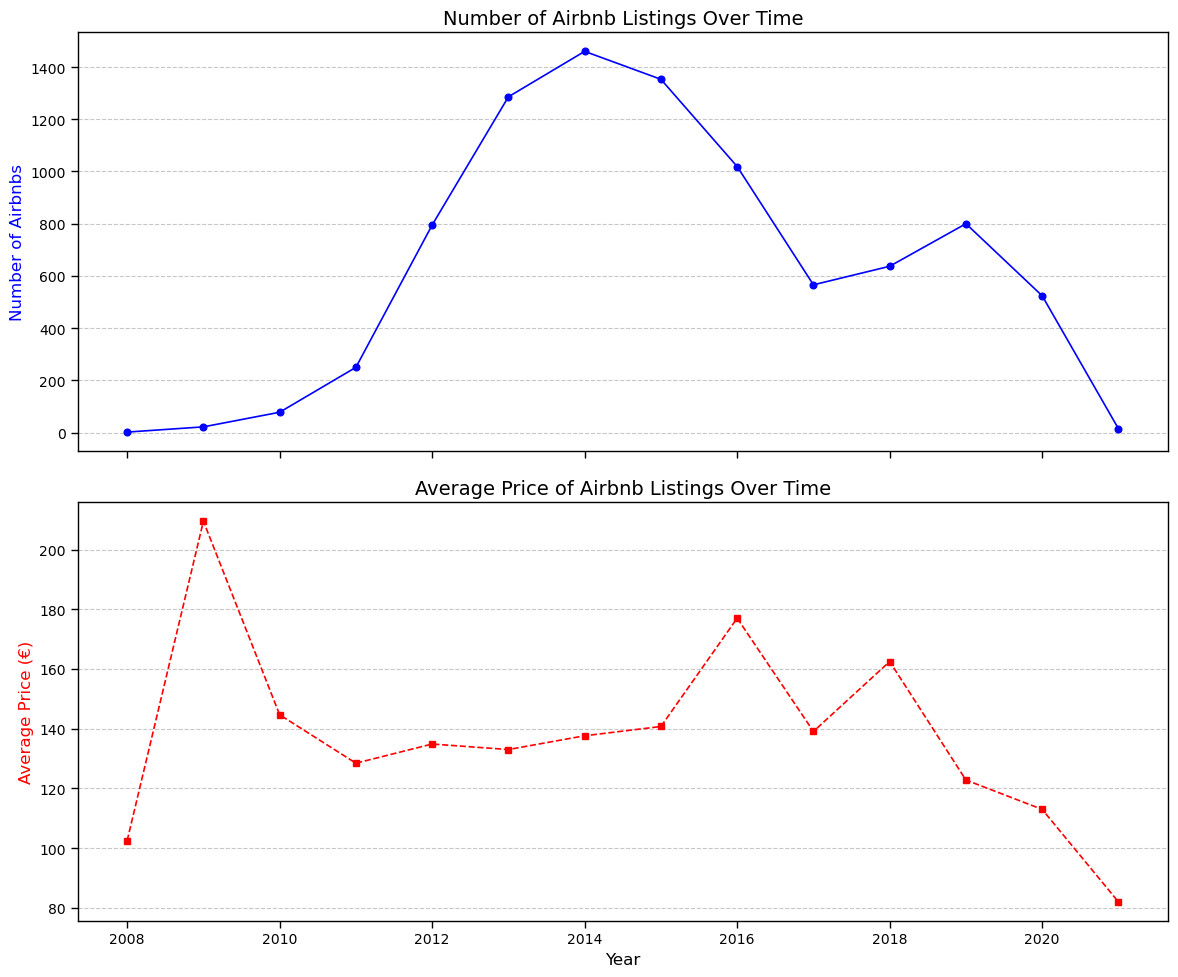

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12,10), sharex=True)

# Plot number of Airbnbs over time
axes[0].plot(dfp_over_time["host_year"], dfp_over_time["total_hosts"], marker='o', linestyle='-', color='b')
axes[0].set_ylabel("Number of Airbnbs", fontsize=12, color='b')
axes[0].set_title("Number of Airbnb Listings Over Time", fontsize=14)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot average price over time
axes[1].plot(dfp_over_time["host_year"], dfp_over_time["avg_price"], marker='s', linestyle='--', color='r')
axes[1].set_xlabel("Year", fontsize=12)
axes[1].set_ylabel("Average Price (€)", fontsize=12, color='r')
axes[1].set_title("Average Price of Airbnb Listings Over Time", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

## 2) Average price by neighborhood

In [24]:
dfp_neighborhood = dfp.groupby("neighbourhood").agg({"price":"mean"}).sort_values("price",ascending=False)
dfp_neighborhood

,price
neighbourhood,
Elysee,216.801512
Louvre,205.094298
Bourse,200.488954
Luxembourg,189.665008
Passy,172.657019
Temple,172.579583
Gobelins,172.395349
Palais-Bourbon,171.239741
Hotel-de-Ville,167.478964


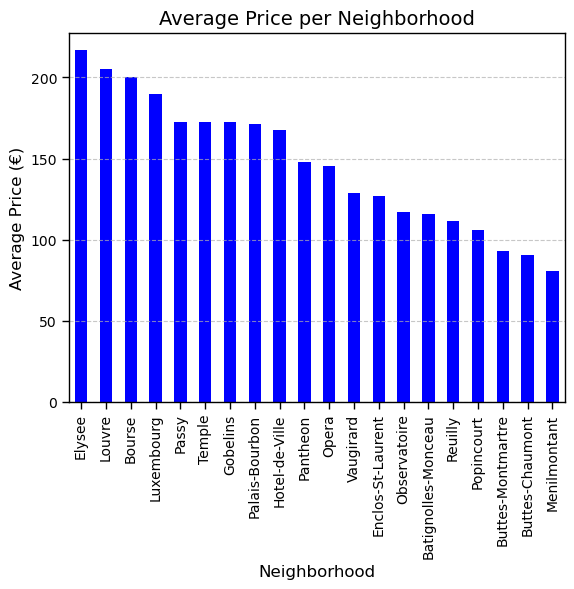

In [25]:
dfp_neighborhood.plot(kind='bar', legend=False, color='blue')

# Customize
plt.title("Average Price per Neighborhood", fontsize=14)
plt.xlabel("Neighborhood", fontsize=12)
plt.ylabel("Average Price (€)", fontsize=12)
plt.xticks(rotation=90) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 3) Average price by number of accommodates

In [26]:
dfp_accommodates = dfp.groupby("accommodates").agg({"price":"mean"}).sort_values("price",ascending=False)
dfp_accommodates

,price
accommodates,
15,944.062500
12,804.448276
11,726.555556
14,721.150000
13,707.000000
16,637.142857
10,563.425197
9,406.725490
8,292.725131


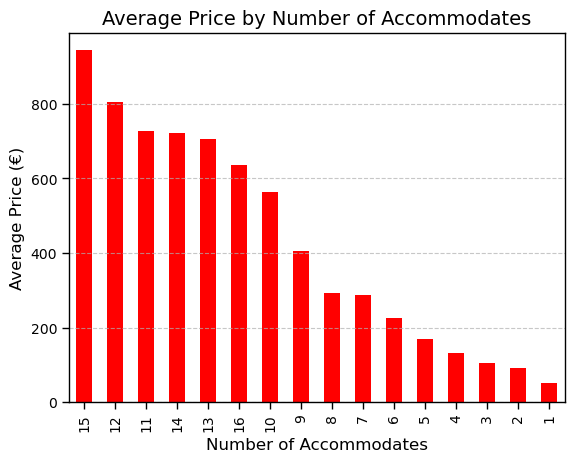

In [27]:
dfp_accommodates.plot(kind='bar', legend=False, color='red')

# Customize
plt.title("Average Price by Number of Accommodates", fontsize=14)
plt.xlabel("Number of Accommodates", fontsize=12)
plt.ylabel("Average Price (€)", fontsize=12)
plt.xticks(rotation=90) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 4) Average price by number of bedrooms

In [28]:
dfp_bed = dfp.groupby("bedrooms").agg({"price":"mean"}).sort_values("bedrooms",ascending=True)
dfp_bed

,price
bedrooms,
1.0,96.155610
2.0,188.817730
3.0,281.585170
4.0,477.352740
5.0,619.090909
6.0,1135.090909
7.0,890.200000
9.0,460.000000
12.0,999.000000


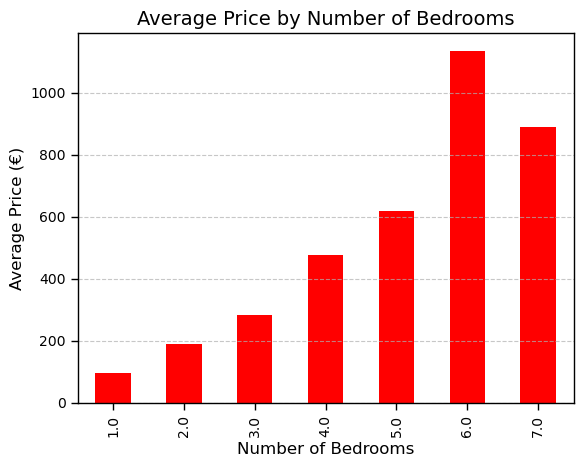

In [29]:
dfp_bed.plot(kind='bar', legend=False, color='red')

# Customize
plt.title("Average Price by Number of Bedrooms", fontsize=14)
plt.xlabel("Number of Bedrooms", fontsize=12)
plt.ylabel("Average Price (€)", fontsize=12)
plt.xticks(rotation=90) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-0.5, 6.5) 

plt.show()

## Regressions


Based on intuition, I pick the following regressions

In [30]:
# Create dummy variables for 'object variables'

dfp = pd.get_dummies(dfp, columns=['neighbourhood'], drop_first=True)
dfp = pd.get_dummies(dfp, columns=['instant_bookable'], drop_first=True)

dfp.head()

,host_id,host_since,host_response_rate,host_acceptance_rate,host_total_listings_count,accommodates,bedrooms,amenities,price,minimum_nights,...,neighbourhood_Observatoire,neighbourhood_Opera,neighbourhood_Palais-Bourbon,neighbourhood_Pantheon,neighbourhood_Passy,neighbourhood_Popincourt,neighbourhood_Reuilly,neighbourhood_Temple,neighbourhood_Vaugirard,instant_bookable_t
14893,305389411,2019-10-30,1.0,1.0,1.0,2,1.0,"[""Shampoo"", ""Dishes and silverware"", ""Heating""...",89,1,...,False,False,False,False,False,True,False,False,False,True
14894,312774780,2019-11-28,1.0,1.0,1.0,4,1.0,"[""Elevator"", ""Dishes and silverware"", ""Hangers...",98,1,...,False,False,False,False,False,False,False,False,False,False
14895,314090203,2019-12-03,1.0,1.0,1.0,2,1.0,"[""Shampoo"", ""Oven"", ""Heating"", ""Washer"", ""Dedi...",75,1,...,False,False,False,False,False,True,False,False,False,False
14896,4263009,2012-11-27,1.0,1.0,1.0,3,1.0,"[""Free street parking"", ""Shampoo"", ""Dishes and...",75,5,...,True,False,False,False,False,False,False,False,False,False
14897,6577904,2013-05-26,1.0,1.0,1.0,4,1.0,"[""Wifi"", ""Washer"", ""Long term stays allowed"", ...",90,10,...,False,False,False,False,False,False,False,False,False,False


In [31]:
# To include the amenities variable in my model, I decided to count the number of amenities present at each listing. 
# While I recognize that some amenities may have more influence than others, this approach was the most feasible option 
# I found to incorporate the variable into the analysis.

def count_amenities(amenities_str):
        # Convert string representation of a list into an actual list
        amenities_list = eval(amenities_str)  
        return len(amenities_list) if isinstance(amenities_list, list) else 0

# Apply function to create 'num_amenities'
dfp['num_amenities'] = dfp['amenities'].apply(count_amenities)

print(dfp[['amenities', 'num_amenities']].head())

# I drop the amenities variable since its an object
columns_to_drop = ['amenities']
# Drop columns
dfp = dfp.drop(columns=columns_to_drop, errors='ignore')


                                               amenities  num_amenities
14893  ["Shampoo", "Dishes and silverware", "Heating"...             16
14894  ["Elevator", "Dishes and silverware", "Hangers...             21
14895  ["Shampoo", "Oven", "Heating", "Washer", "Dedi...             19
14896  ["Free street parking", "Shampoo", "Dishes and...             18
14897  ["Wifi", "Washer", "Long term stays allowed", ...              4


In [32]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13690 entries, 14893 to 56178
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   host_id                          13690 non-null  int64         
 1   host_since                       13690 non-null  datetime64[ns]
 2   host_response_rate               13690 non-null  float64       
 3   host_acceptance_rate             13690 non-null  float64       
 4   host_total_listings_count        13690 non-null  float64       
 5   accommodates                     13690 non-null  int64         
 6   bedrooms                         13690 non-null  float64       
 7   price                            13690 non-null  int64         
 8   minimum_nights                   13690 non-null  int64         
 9   maximum_nights                   13690 non-null  int64         
 10  review_scores_rating             13690 non-null  float64   

In [33]:
# Compute correlation of all variables with price to get an idea of what variables are good predictors
price_correlation = dfp.corr()['price'].drop('price')

# Display correlation values
price_correlation.sort_values(ascending=False)

accommodates                       0.341051
bedrooms                           0.193741
num_amenities                      0.072338
instant_bookable_t                 0.064192
host_total_listings_count          0.058592
neighbourhood_Elysee               0.056742
neighbourhood_Bourse               0.050580
host_acceptance_rate               0.049367
neighbourhood_Louvre               0.044328
neighbourhood_Luxembourg           0.038752
maximum_nights                     0.037937
neighbourhood_Temple               0.030974
review_scores_cleanliness          0.027603
neighbourhood_Passy                0.026814
host_response_rate                 0.025210
neighbourhood_Hotel-de-Ville       0.021035
neighbourhood_Gobelins             0.020765
neighbourhood_Palais-Bourbon       0.020758
review_scores_location             0.012587
review_scores_rating               0.012119
neighbourhood_Pantheon             0.004830
neighbourhood_Opera                0.003331
host_year                       

Based on the results, I will include accommodates, bedrooms, num_amenities, instant_bookable_t, and host_total_listings_count as the five strongest predictors of price. The other variables have very low correlation coefficients, indicating little to no relationship with price.

In [34]:
# Create new dataframe with only the selected variables.

dfpr = dfp[['price', 'accommodates', 'bedrooms', 'num_amenities', 'instant_bookable_t', 'host_total_listings_count']]
# reset the index so it starts from 0 and not from 14893.
dfpr = dfpr.reset_index(drop=True)
dfpr

,price,accommodates,bedrooms,num_amenities,instant_bookable_t,host_total_listings_count
0,89,2,1.0,16,True,1.0
1,98,4,1.0,21,False,1.0
2,75,2,1.0,19,False,1.0
3,75,3,1.0,18,False,1.0
4,90,4,1.0,4,False,1.0
...,...,...,...,...,...,...
13685,159,5,1.0,21,False,1.0
13686,99,3,1.0,18,True,1.0
13687,80,3,1.0,30,False,1.0
13688,62,3,1.0,14,False,1.0


In [35]:
#To ensure our model and predictions are meaningful, I grouped the listing prices into four bins.


# Define price bins (adjust as needed)
bins = [0, 67, 96, 153, 12000]  # Define the boundaries
labels = [1, 2, 3, 4]  # Assign category labels (1 = <25%, 2 = 25-50%, 3 = 50-75%, 4 =  >75%)

# Create a new categorical price column
dfpr['price_category'] = pd.cut(dfpr['price'], bins=bins, labels=labels, include_lowest=True)

# Drop the original price column since we're now predicting categories
dfpr = dfpr.drop(columns=['price'])

dfpr.head()

,accommodates,bedrooms,num_amenities,instant_bookable_t,host_total_listings_count,price_category
0,2,1.0,16,True,1.0,2
1,4,1.0,21,False,1.0,3
2,2,1.0,19,False,1.0,2
3,3,1.0,18,False,1.0,2
4,4,1.0,4,False,1.0,2


In [36]:
print(dfpr['price_category'].value_counts())


price_category
1    3460
3    3414
4    3414
2    3402
Name: count, dtype: int64


In [37]:
dfpr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13690 entries, 0 to 13689
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   accommodates               13690 non-null  int64   
 1   bedrooms                   13690 non-null  float64 
 2   num_amenities              13690 non-null  int64   
 3   instant_bookable_t         13690 non-null  bool    
 4   host_total_listings_count  13690 non-null  float64 
 5   price_category             13690 non-null  category
dtypes: bool(1), category(1), float64(2), int64(2)
memory usage: 454.9 KB


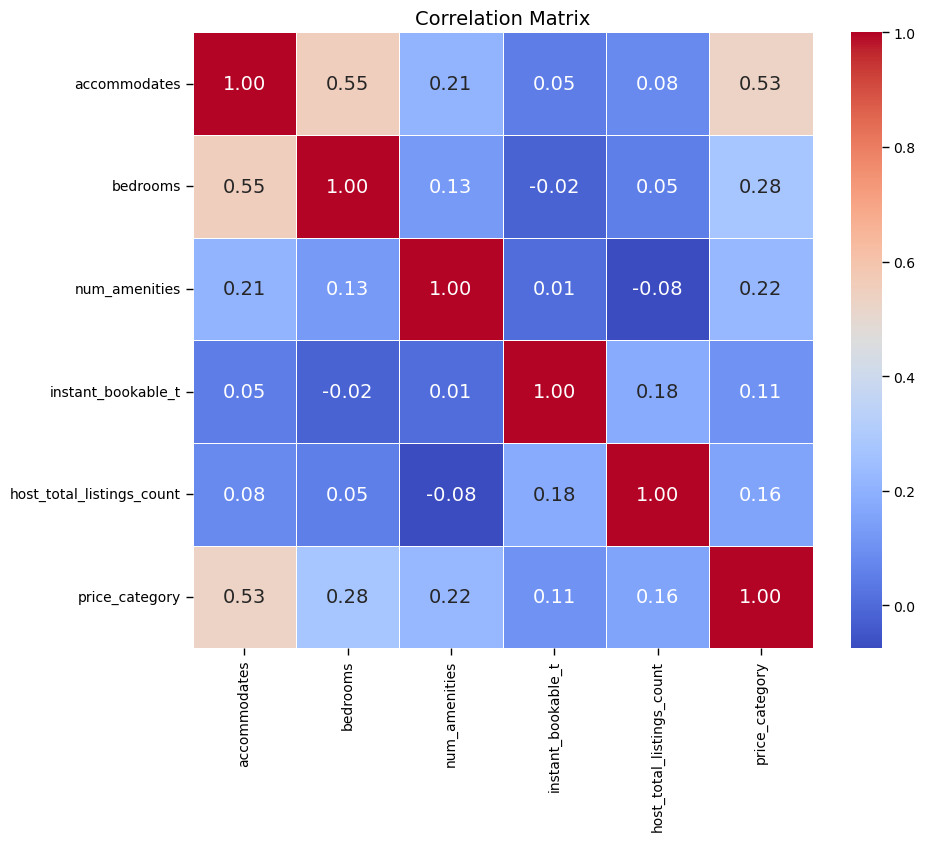

In [38]:
correlation_matrix = dfpr.corr()

# Display correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

C:\Users\Eelen\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


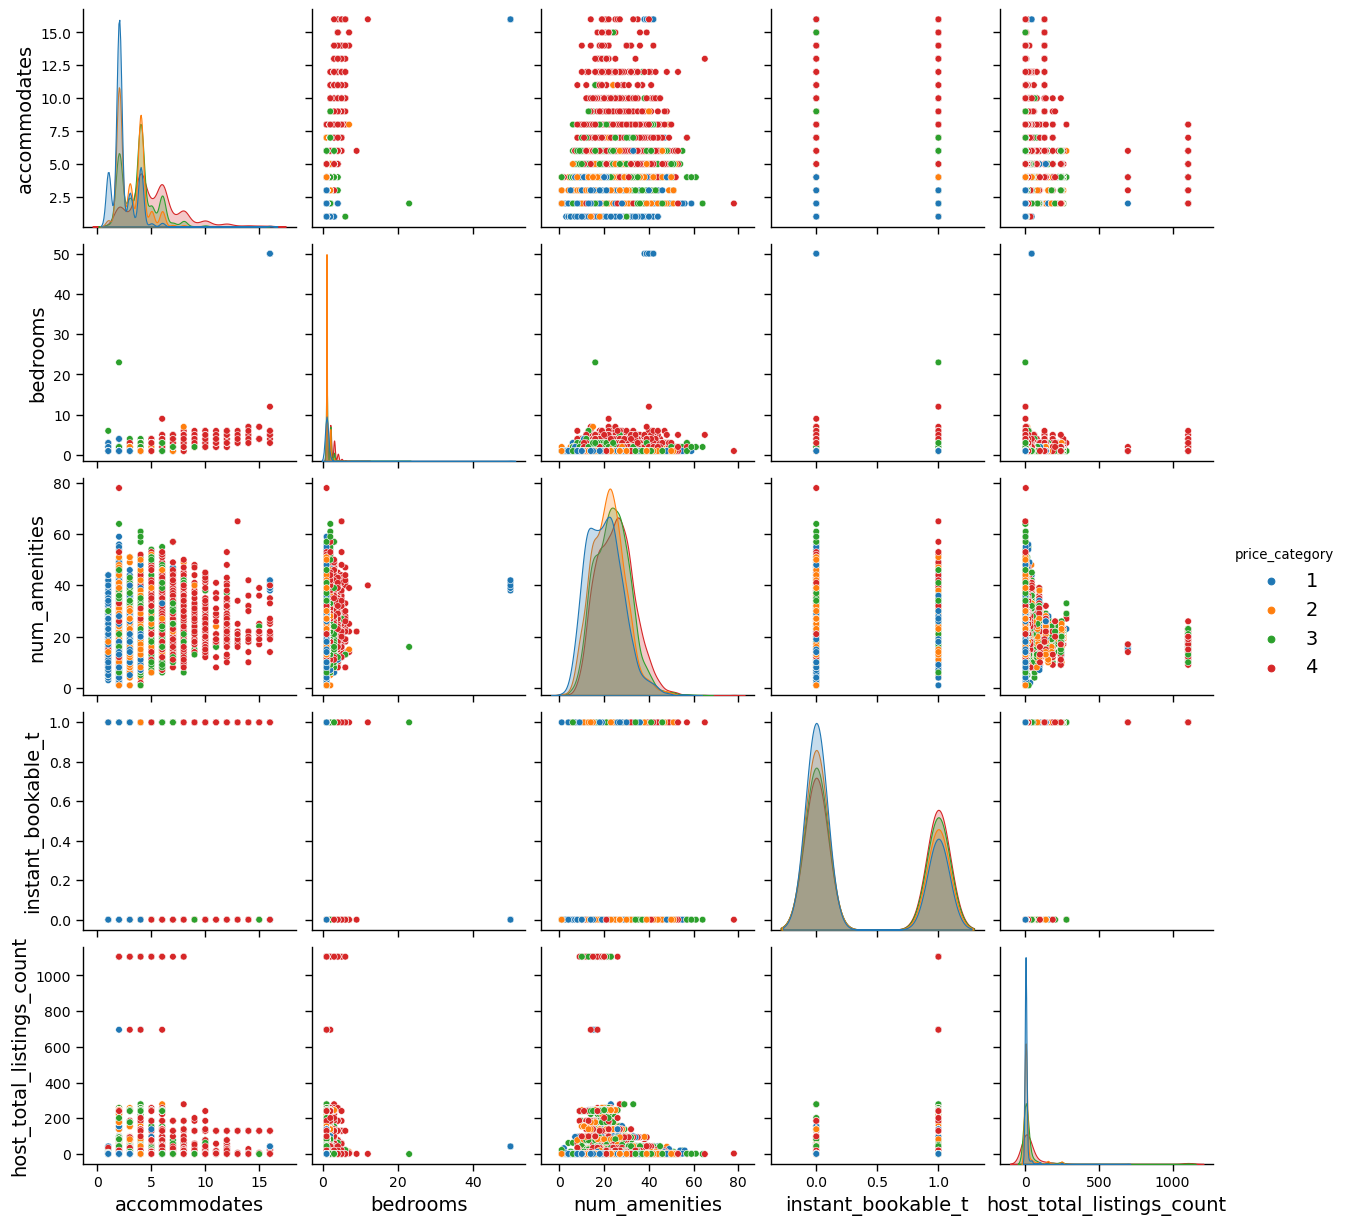

In [39]:
sns.pairplot(dfpr, hue= 'price_category');

Now that our dataset is fully cleaned and prepared, I decided to use logistic regression since the dependent variable (price) is now categorical.

In [40]:
# we first start with splitting our dataset into a training set and a test set
# I chose an 80/20 train-test split to balance model learning and evaluation.


train_set, test_set = train_test_split(dfpr, test_size=0.2, random_state=42)
train_set.info(), test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10952 entries, 3562 to 7270
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   accommodates               10952 non-null  int64   
 1   bedrooms                   10952 non-null  float64 
 2   num_amenities              10952 non-null  int64   
 3   instant_bookable_t         10952 non-null  bool    
 4   host_total_listings_count  10952 non-null  float64 
 5   price_category             10952 non-null  category
dtypes: bool(1), category(1), float64(2), int64(2)
memory usage: 449.4 KB
<class 'pandas.core.frame.DataFrame'>
Index: 2738 entries, 9309 to 9603
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   accommodates               2738 non-null   int64   
 1   bedrooms                   2738 non-null   float64 
 2   num_amenities              2

(None, None)

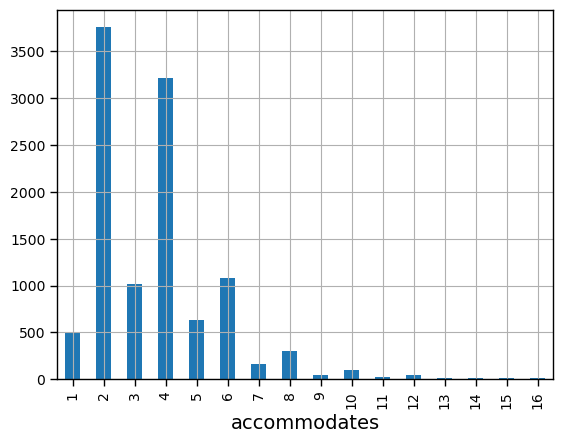

In [41]:
# Now i check if i need to stratify. 

train_set['accommodates'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

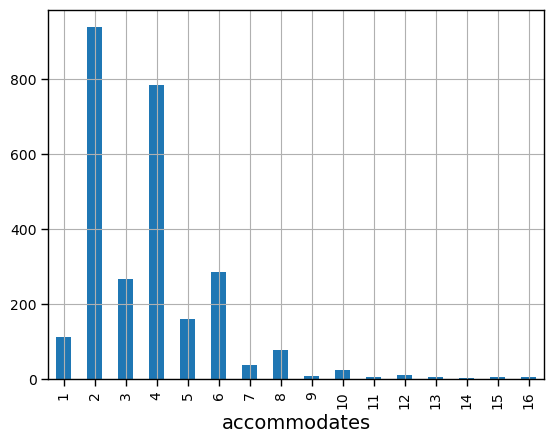

In [42]:
test_set['accommodates'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

In [43]:
# After comparing the plots of the train and test sets, i conclude that there is no need to stratify. 

In [44]:
# According to class06: "For machine learning models, ideally we want all of our features to be of similar scale (that is generally 0:1 in the case of regressors"
# Therefore, I will be scaling all of them because they all have different ranges.

xsk1_train = np.array(train_set[["accommodates"]])
xsk2_train = np.array(train_set[["bedrooms"]])
xsk3_train = np.array(train_set[["num_amenities"]])
xsk4_train = np.array(train_set[["host_total_listings_count"]])


xsk1_test = np.array(test_set[["accommodates"]])
xsk2_test = np.array(test_set[["bedrooms"]])
xsk3_test = np.array(test_set[["num_amenities"]])
xsk4_test = np.array(test_set[["host_total_listings_count"]])

# here are all of my target species, from the training set
y_train_1 = train_set[["price_category"]] == 1; yv_train_1 = y_train_1.values
yr_train_1 = yv_train_1.ravel() # correcting shape for error

y_train_2 = train_set[["price_category"]] == 2; yv_train_2 = y_train_2.values
yr_train_2 = yv_train_2.ravel() # correcting shape for error

y_train_3 = train_set[["price_category"]] == 3; yv_train_3 = y_train_3.values
yr_train_3 = yv_train_3.ravel() # correcting shape for error

y_train_4 = train_set[["price_category"]] == 4; yv_train_4 = y_train_4.values
yr_train_4 = yv_train_4.ravel() # correcting shape for error




y_test_1 = test_set[["price_category"]] == 1; yv_test_1 = y_test_1.values
yr_test_1 = yv_test_1.ravel() # correcting shape for error
y_test_2 = test_set[["price_category"]] == 2; yv_test_2 = y_test_2.values
yr_test_2 = yv_test_2.ravel() # correcting shape for error
y_test_3 = test_set[["price_category"]] == 3; yv_test_3 = y_test_3.values
yr_test_3 = yv_test_3.ravel() # correcting shape for error
y_test_4 = test_set[["price_category"]] == 3; yv_test_4 = y_test_4.values
yr_test_4 = yv_test_4.ravel() # correcting shape for error





feat_scaleracc = StandardScaler(with_mean=True, with_std=True) #to scale accommodates 
feat_scalerbed = StandardScaler(with_mean=True, with_std=True) # to scale bedrooms 
feat_scaleram = StandardScaler(with_mean=True, with_std=True) #to scale num_amenities
feat_scalerhost = StandardScaler(with_mean=True, with_std=True) # to scale host_total_listings_count



# and here are those scaled feature values that we will fit/test with our model
scaled_acc_train = feat_scaleracc.fit_transform(train_set[["accommodates"]])
scaled_bed_train = feat_scalerbed.fit_transform(train_set[["bedrooms"]])
scaled_am_train = feat_scaleram.fit_transform(train_set[["num_amenities"]])
scaled_host_train = feat_scalerhost.fit_transform(train_set[["host_total_listings_count"]])


scaled_acc_test = feat_scaleracc.transform(test_set[["accommodates"]])
scaled_bed_test = feat_scalerbed.transform(test_set[["bedrooms"]])
scaled_am_test = feat_scaleram.transform(test_set[["num_amenities"]])
scaled_host_test = feat_scalerhost.transform(test_set[["host_total_listings_count"]])


## Univariate models

## Predicting price (bottom 25%) based on number of accommodates

In [45]:
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_train.ravel()
#ysk_sr_test = ysk_test.ravel()

log_reg.fit(scaled_acc_train, yr_train_1)

# Predictions & Probabilities
proba = log_reg.predict_proba(scaled_acc_train)  
probat = log_reg.predict_proba(scaled_acc_test)   
pred_test = log_reg.predict(scaled_acc_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_acc_train, yr_train_1, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_acc_test, yr_test_1, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_acc = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_1[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_1),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_1[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_1)
}

In [46]:
accuracy_results_acc

{'Training Set Accuracy (Cross-Validated)': 0.7773922793328456,
 'Test Set Accuracy (Cross-Validated)': 0.7815950306249084,
 'Predicted Low-Price Listings (Training Set)': 2028,
 'Actual Low-Price Listings (Training Set)': 2783,
 'Predicted Low-Price Listings (Test Set)': 469,
 'Actual Low-Price Listings (Test Set)': 677}

## Predicting price (bottom 25%) based on number of bedrooms


In [47]:
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_train.ravel()
#ysk_sr_test = ysk_test.ravel()

log_reg.fit(scaled_bed_train, yr_train_1)

# Predictions & Probabilities
proba = log_reg.predict_proba(scaled_bed_train)  
probat = log_reg.predict_proba(scaled_bed_test)   
pred_test = log_reg.predict(scaled_bed_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_bed_train, yr_train_1, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_bed_test, yr_test_1, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_bed = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_1[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_1),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_1[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_1)
}

In [48]:
accuracy_results_bed

{'Training Set Accuracy (Cross-Validated)': 0.7458911820669447,
 'Test Set Accuracy (Cross-Validated)': 0.7527395615100281,
 'Predicted Low-Price Listings (Training Set)': 2659,
 'Actual Low-Price Listings (Training Set)': 2783,
 'Predicted Low-Price Listings (Test Set)': 647,
 'Actual Low-Price Listings (Test Set)': 677}

## Predicting price (bottom 25%) based on number of amenities


In [49]:
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_train.ravel()
#ysk_sr_test = ysk_test.ravel()

log_reg.fit(scaled_am_train, yr_train_1)

# Predictions & Probabilities
proba = log_reg.predict_proba(scaled_am_train)  
probat = log_reg.predict_proba(scaled_am_test)   
pred_test = log_reg.predict(scaled_am_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_am_train, yr_train_1, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_am_test, yr_test_1, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_am = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_1[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_1),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_1[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_1)
}

In [50]:
accuracy_results_am

{'Training Set Accuracy (Cross-Validated)': 0.7458911820669447,
 'Test Set Accuracy (Cross-Validated)': 0.7527395615100281,
 'Predicted Low-Price Listings (Training Set)': 1142,
 'Actual Low-Price Listings (Training Set)': 2783,
 'Predicted Low-Price Listings (Test Set)': 251,
 'Actual Low-Price Listings (Test Set)': 677}

## Predicting price (bottom 25%) based on number of total listings the host has


In [51]:
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_train.ravel()
#ysk_sr_test = ysk_test.ravel()

log_reg.fit(scaled_host_train, yr_train_1)

# Predictions & Probabilities
proba = log_reg.predict_proba(scaled_host_train)  
probat = log_reg.predict_proba(scaled_host_test)   
pred_test = log_reg.predict(scaled_host_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, scaled_host_train, yr_train_1, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, scaled_host_test, yr_test_1, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_host = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_1[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_1),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_1[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_1)
}

In [52]:
accuracy_results_host

{'Training Set Accuracy (Cross-Validated)': 0.7458911820669447,
 'Test Set Accuracy (Cross-Validated)': 0.7527395615100281,
 'Predicted Low-Price Listings (Training Set)': 0,
 'Actual Low-Price Listings (Training Set)': 2783,
 'Predicted Low-Price Listings (Test Set)': 0,
 'Actual Low-Price Listings (Test Set)': 677}

## Summary of results

In [53]:
print("Univariate Model 1: Predicting low price (<25%) based on number of accommodates")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_acc['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_acc['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_acc['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_acc['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_acc['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_acc['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

print("Univariate Model 2: Predicting low price (<25%) based on number of bedrooms")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_bed['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_bed['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_bed['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_bed['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_bed['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_bed['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

print("Univariate Model 3: Predicting low price (<25%) based on number of amenities")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_am['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_am['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_am['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_am['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_am['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_am['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

print("Univariate Model 4: Predicting low price (<25%) based on number of total listings of the host")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_host['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_host['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_host['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_host['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_host['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_host['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

Univariate Model 1: Predicting low price (<25%) based on number of accommodates
Training Set Accuracy (Cross-Validated): 0.777
Test Set Accuracy (Cross-Validated): 0.782
Predicted Low-Price Listings (Train): 2028 / 2783
Predicted Low-Price Listings (Test): 469 / 677
--------------------------------------------------
Univariate Model 2: Predicting low price (<25%) based on number of bedrooms
Training Set Accuracy (Cross-Validated): 0.746
Test Set Accuracy (Cross-Validated): 0.753
Predicted Low-Price Listings (Train): 2659 / 2783
Predicted Low-Price Listings (Test): 647 / 677
--------------------------------------------------
Univariate Model 3: Predicting low price (<25%) based on number of amenities
Training Set Accuracy (Cross-Validated): 0.746
Test Set Accuracy (Cross-Validated): 0.753
Predicted Low-Price Listings (Train): 1142 / 2783
Predicted Low-Price Listings (Test): 251 / 677
--------------------------------------------------
Univariate Model 4: Predicting low price (<25%) based

## Multivariate models

## Predicting price (<25%) based on all variables

In [54]:
X_train_scaled = np.hstack([
    scaled_acc_train, scaled_bed_train, scaled_am_train, 
    scaled_host_train
])
X_test_scaled = np.hstack([
    scaled_acc_test, scaled_bed_test, scaled_am_test, 
    scaled_host_test
])

# Train logistic regression model
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_s_train.ravel()
#ysk_sr_test = ysk_s_test.ravel()

log_reg.fit(X_train_scaled, yr_train_1)

# Predictions & Probabilities
proba = log_reg.predict_proba(X_train_scaled)  
probat = log_reg.predict_proba(X_test_scaled)   
pred_test = log_reg.predict(X_test_scaled)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train_scaled, yr_train_1, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test_scaled, yr_test_1, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_multivariable1 = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_1[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_1),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_1[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_1)
}


In [55]:
accuracy_results_multivariable1

{'Training Set Accuracy (Cross-Validated)': 0.7856095817468306,
 'Test Set Accuracy (Cross-Validated)': 0.7899905256275103,
 'Predicted Low-Price Listings (Training Set)': 2074,
 'Actual Low-Price Listings (Training Set)': 2783,
 'Predicted Low-Price Listings (Test Set)': 483,
 'Actual Low-Price Listings (Test Set)': 677}

## Predicting price (25% - 50%) based on all variables

In [56]:
X_train_scaled = np.hstack([
    scaled_acc_train, scaled_bed_train, scaled_am_train, 
    scaled_host_train
])
X_test_scaled = np.hstack([
    scaled_acc_test, scaled_bed_test, scaled_am_test, 
    scaled_host_test
])

# Train logistic regression model
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_s_train.ravel()
#ysk_sr_test = ysk_s_test.ravel()

log_reg.fit(X_train_scaled, yr_train_2)

# Predictions & Probabilities
proba = log_reg.predict_proba(X_train_scaled)  
probat = log_reg.predict_proba(X_test_scaled)   
pred_test = log_reg.predict(X_test_scaled)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train_scaled, yr_train_2, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test_scaled, yr_test_2, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_multivariable2 = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_2[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_2),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_2[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_2)
}


In [57]:
accuracy_results_multivariable2

{'Training Set Accuracy (Cross-Validated)': 0.7517348472059837,
 'Test Set Accuracy (Cross-Validated)': 0.7505484460694699,
 'Predicted Low-Price Listings (Training Set)': 1573,
 'Actual Low-Price Listings (Training Set)': 2719,
 'Predicted Low-Price Listings (Test Set)': 407,
 'Actual Low-Price Listings (Test Set)': 683}

## Predicting price (50% - 75%) based on all variables

In [58]:
X_train_scaled = np.hstack([
    scaled_acc_train, scaled_bed_train, scaled_am_train, 
    scaled_host_train
])
X_test_scaled = np.hstack([
    scaled_acc_test, scaled_bed_test, scaled_am_test, 
    scaled_host_test
])

# Train logistic regression model
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_s_train.ravel()
#ysk_sr_test = ysk_s_test.ravel()

log_reg.fit(X_train_scaled, yr_train_3)

# Predictions & Probabilities
proba = log_reg.predict_proba(X_train_scaled)  
probat = log_reg.predict_proba(X_test_scaled)   
pred_test = log_reg.predict(X_test_scaled)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train_scaled, yr_train_3, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test_scaled, yr_test_3, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_multivariable3 = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_3[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_3),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_3[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_3)
}


In [59]:
accuracy_results_multivariable3

{'Training Set Accuracy (Cross-Validated)': 0.7510044203247407,
 'Test Set Accuracy (Cross-Validated)': 0.747261105699302,
 'Predicted Low-Price Listings (Training Set)': 568,
 'Actual Low-Price Listings (Training Set)': 2722,
 'Predicted Low-Price Listings (Test Set)': 140,
 'Actual Low-Price Listings (Test Set)': 692}

## Predicting price (>75%) based on all variables

In [60]:
X_train_scaled = np.hstack([
    scaled_acc_train, scaled_bed_train, scaled_am_train, 
    scaled_host_train
])
X_test_scaled = np.hstack([
    scaled_acc_test, scaled_bed_test, scaled_am_test, 
    scaled_host_test
])

# Train logistic regression model
log_reg = LogisticRegression(random_state=42)
#ysk_sr_train = ysk_s_train.ravel()
#ysk_sr_test = ysk_s_test.ravel()

log_reg.fit(X_train_scaled, yr_train_4)

# Predictions & Probabilities
proba = log_reg.predict_proba(X_train_scaled)  
probat = log_reg.predict_proba(X_test_scaled)   
pred_test = log_reg.predict(X_test_scaled)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train_scaled, yr_train_4, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test_scaled, yr_test_4, cv=5, scoring="accuracy").mean()

# Store accuracy results
# I chose the probability threshold to be 0.3 since there are 4 categories. 
accuracy_results_multivariable4 = {
    "Training Set Accuracy (Cross-Validated)": train_accuracy,
    "Test Set Accuracy (Cross-Validated)": test_accuracy,
    "Predicted Low-Price Listings (Training Set)": np.sum(yv_train_4[proba[:,1] > 0.3]),
    "Actual Low-Price Listings (Training Set)": np.sum(yr_train_4),
    "Predicted Low-Price Listings (Test Set)": np.sum(yv_test_4[probat[:,1] > 0.3]),
    "Actual Low-Price Listings (Test Set)": np.sum(yr_test_4)
}

In [61]:
accuracy_results_multivariable4

{'Training Set Accuracy (Cross-Validated)': 0.8171112625539514,
 'Test Set Accuracy (Cross-Validated)': 0.747261105699302,
 'Predicted Low-Price Listings (Training Set)': 1713,
 'Actual Low-Price Listings (Training Set)': 2728,
 'Predicted Low-Price Listings (Test Set)': 201,
 'Actual Low-Price Listings (Test Set)': 692}

## Summary of results

In [62]:
print("Multivariable Model 1: Predicting low price (<25%) based on all variables")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_multivariable1['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_multivariable1['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_multivariable1['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_multivariable1['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_multivariable1['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_multivariable1['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

print("Multivariable Model 2: Predicting low-medium price (25% - 50%) based on all variables")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_multivariable2['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_multivariable2['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_multivariable2['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_multivariable2['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_multivariable2['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_multivariable2['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

print("Multivariable Model 3: Predicting medium-high price (50% - 75%) based on all variables")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_multivariable3['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_multivariable3['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_multivariable3['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_multivariable3['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_multivariable3['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_multivariable3['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

print("Multivariable Model 4: Predicting high price (>75%) based on all variables")
print(f"Training Set Accuracy (Cross-Validated): {accuracy_results_multivariable4['Training Set Accuracy (Cross-Validated)']:.3f}")
print(f"Test Set Accuracy (Cross-Validated): {accuracy_results_multivariable4['Test Set Accuracy (Cross-Validated)']:.3f}")
print(f"Predicted Low-Price Listings (Train): {accuracy_results_multivariable4['Predicted Low-Price Listings (Training Set)']} / {accuracy_results_multivariable4['Actual Low-Price Listings (Training Set)']}")
print(f"Predicted Low-Price Listings (Test): {accuracy_results_multivariable4['Predicted Low-Price Listings (Test Set)']} / {accuracy_results_multivariable4['Actual Low-Price Listings (Test Set)']}")
print("-" * 50)

Multivariable Model 1: Predicting low price (<25%) based on all variables
Training Set Accuracy (Cross-Validated): 0.786
Test Set Accuracy (Cross-Validated): 0.790
Predicted Low-Price Listings (Train): 2074 / 2783
Predicted Low-Price Listings (Test): 483 / 677
--------------------------------------------------
Multivariable Model 2: Predicting low-medium price (25% - 50%) based on all variables
Training Set Accuracy (Cross-Validated): 0.752
Test Set Accuracy (Cross-Validated): 0.751
Predicted Low-Price Listings (Train): 1573 / 2719
Predicted Low-Price Listings (Test): 407 / 683
--------------------------------------------------
Multivariable Model 3: Predicting medium-high price (50% - 75%) based on all variables
Training Set Accuracy (Cross-Validated): 0.751
Test Set Accuracy (Cross-Validated): 0.747
Predicted Low-Price Listings (Train): 568 / 2722
Predicted Low-Price Listings (Test): 140 / 692
--------------------------------------------------
Multivariable Model 4: Predicting high p